QUANTUM STOCHASTIC DIFFERENTIAL EQUATIONS: COMPREHENSIVE SIMULATIONS

1. Simulating amplitude damping (photon loss)...
   ✓ Complete
2. Simulating phase damping (decoherence)...
   ✓ Complete
3. Simulating thermal bath equilibration...
   ✓ Complete
4. Comparing master equation with quantum trajectories...
   ✓ Complete
5. Visualizing density matrix evolution...
   ✓ Complete
6. Analyzing quantum channel capacity...
   ✓ Complete

ALL SIMULATIONS COMPLETE

SUMMARY STATISTICS:
----------------------------------------------------------------------

Parameter Estimation Test:
Quadratic form Q matrix shape: (2, 2)
Q matrix (first 2x2 block):
[[  0. 195.]
 [330.   0.]]

Fidelity Calculation Test:
Fidelity between |0⟩ and |1⟩: 0.000000 (should be ~0)
Fidelity between |0⟩ and |0⟩: 1.000000 (should be 1)

Entropy Calculations:
Entropy of pure state: -0.000000 (should be ~0)
Entropy of maximally mixed state: 1.000000 (should be 1.0)



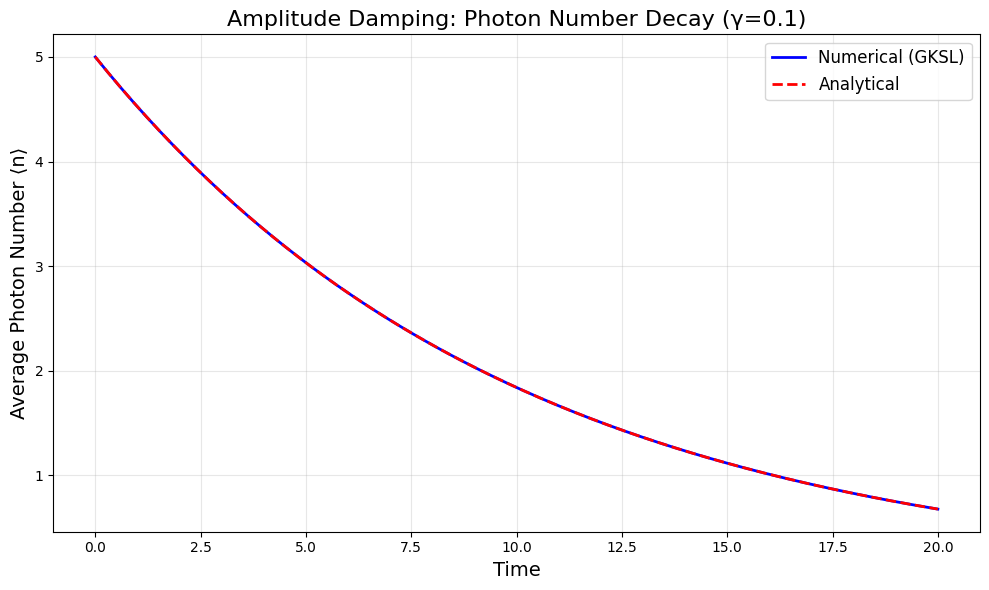

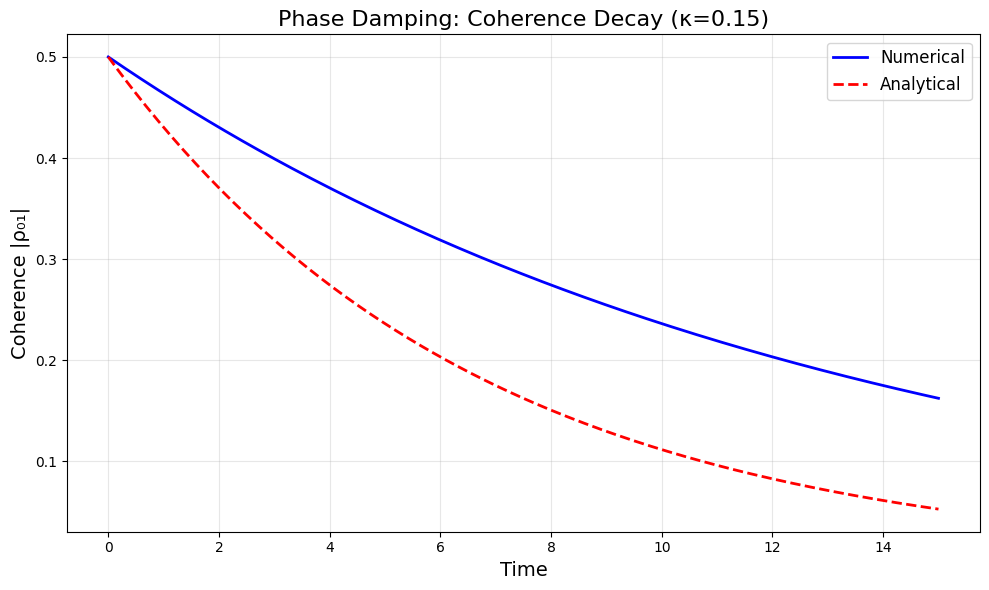

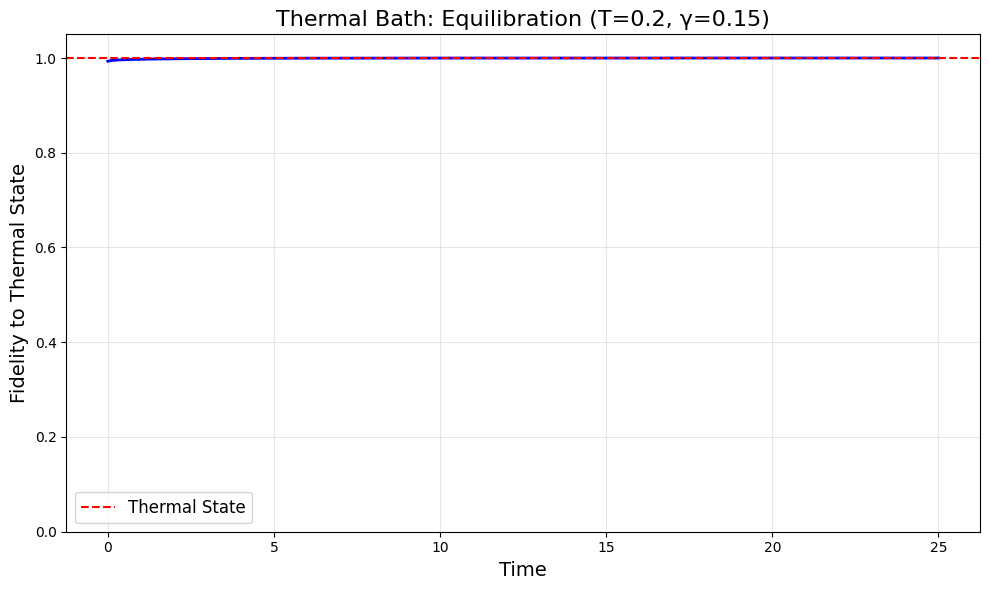

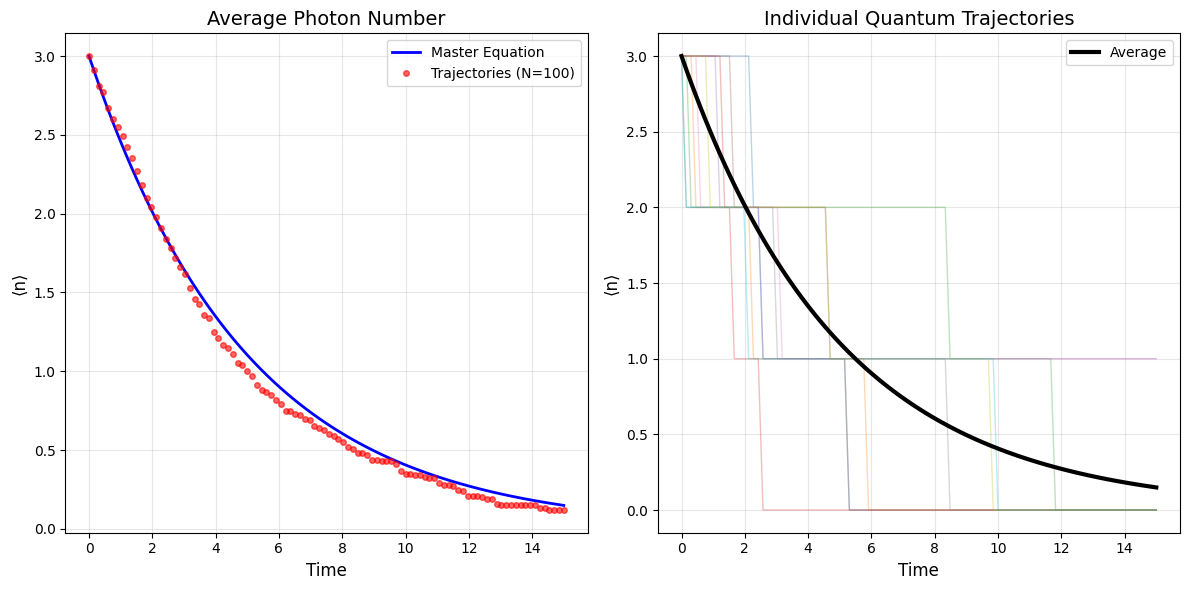

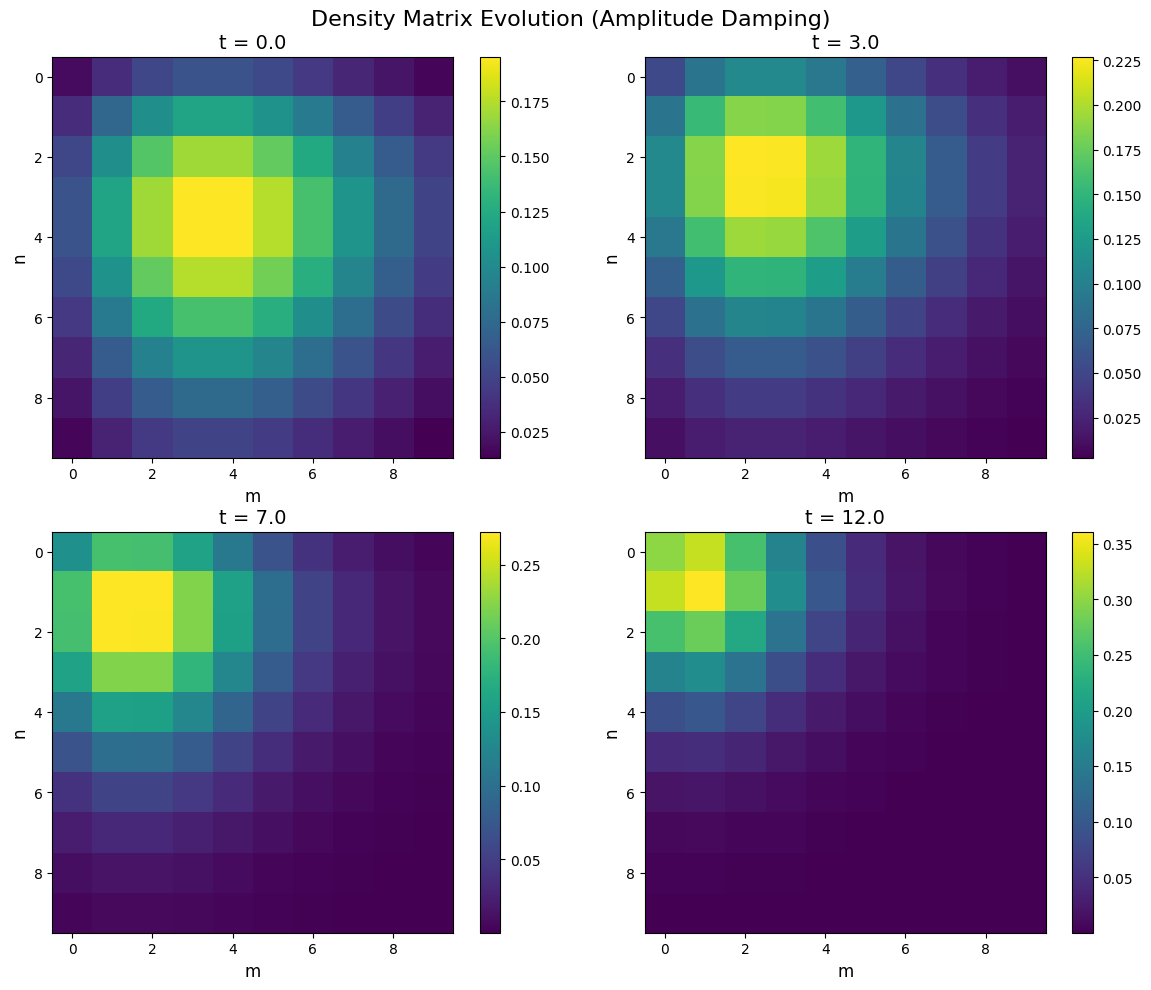

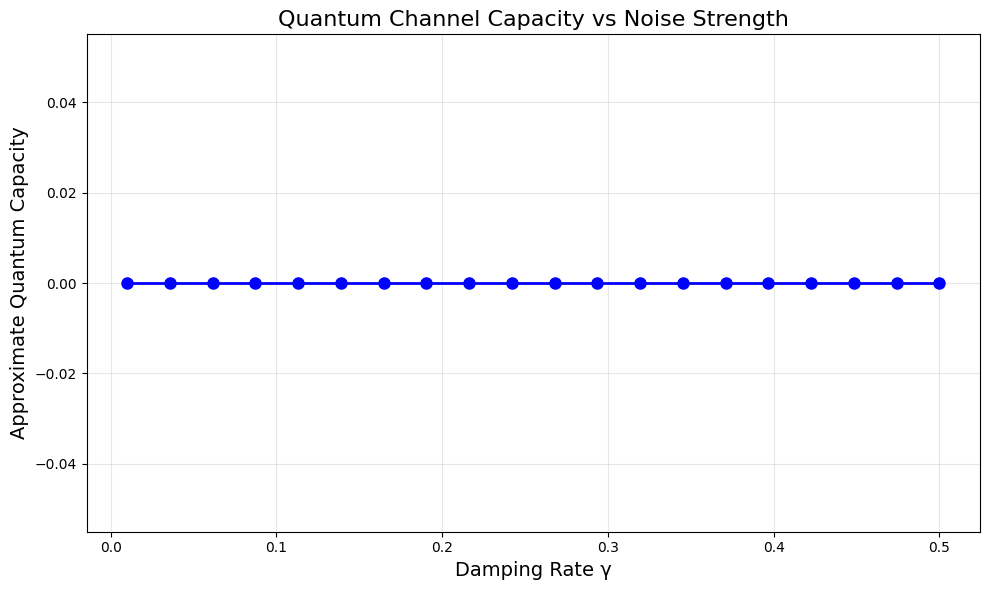

In [1]:
"""
Quantum Stochastic Differential Equations: Comprehensive Simulations
=====================================================================

This module implements:
1. Hudson-Parthasarathy quantum stochastic differential equations
2. GKSL master equation simulations
3. Parameter estimation algorithms
4. Quantum communication protocols
5. Comparison and validation tools

Dependencies:
- qiskit: IBM Quantum framework
- qutip: Quantum Toolbox in Python
- numpy, scipy: Numerical computing
- matplotlib: Visualization
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.special import factorial
from typing import List, Tuple, Callable
import warnings
warnings.filterwarnings('ignore')

# Try importing quantum libraries
try:
    from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
    from qiskit.quantum_info import Operator, DensityMatrix, state_fidelity
    from qiskit_aer import AerSimulator
    QISKIT_AVAILABLE = True
except ImportError:
    print("Warning: Qiskit not available. Using custom implementations.")
    QISKIT_AVAILABLE = False

try:
    import qutip as qt
    QUTIP_AVAILABLE = True
except ImportError:
    print("Warning: QuTiP not available. Using custom implementations.")
    QUTIP_AVAILABLE = False


class QuantumStochasticSystem:
    """
    Base class for quantum systems with stochastic noise
    """
    
    def __init__(self, dim: int, hamiltonian: np.ndarray = None):
        """
        Initialize quantum system
        
        Parameters:
        -----------
        dim : int
            Dimension of Hilbert space
        hamiltonian : np.ndarray
            System Hamiltonian (default: zero)
        """
        self.dim = dim
        self.H = hamiltonian if hamiltonian is not None else np.zeros((dim, dim))
        
    def lindblad_operators(self) -> List[np.ndarray]:
        """Return list of Lindblad operators (to be overridden)"""
        raise NotImplementedError


class AmplitudeDampingChannel(QuantumStochasticSystem):
    """
    Amplitude damping channel: models photon loss
    """
    
    def __init__(self, n_max: int = 10, omega: float = 1.0, gamma: float = 0.1):
        """
        Parameters:
        -----------
        n_max : int
            Fock space truncation
        omega : float
            Oscillator frequency
        gamma : float
            Damping rate
        """
        # Creation and annihilation operators
        self.a = np.diag(np.sqrt(np.arange(1, n_max)), 1)
        self.a_dag = self.a.T
        self.n_op = self.a_dag @ self.a
        
        # Hamiltonian
        H = omega * self.n_op
        
        super().__init__(n_max, H)
        
        self.omega = omega
        self.gamma = gamma
        
    def lindblad_operators(self) -> List[np.ndarray]:
        """Lindblad operator L = sqrt(gamma) * a"""
        return [np.sqrt(self.gamma) * self.a]
    
    def gksl_generator(self, rho: np.ndarray) -> np.ndarray:
        """
        GKSL master equation: drho/dt = L(rho)
        
        L(rho) = -i[H, rho] + gamma(a rho a† - 1/2{a†a, rho})
        """
        # Commutator term
        comm = -1j * (self.H @ rho - rho @ self.H)
        
        # Dissipator term
        L = np.sqrt(self.gamma) * self.a
        dissipator = (L @ rho @ L.conj().T 
                     - 0.5 * (L.conj().T @ L @ rho + rho @ L.conj().T @ L))
        
        return comm + dissipator
    
    def hp_evolution_step(self, U: np.ndarray, dt: float, 
                          dA: complex, dA_dag: complex) -> np.ndarray:
        """
        Hudson-Parthasarathy evolution: single time step
        
        dU = [-(iH + 1/2 L†L)dt + L dA† - L† dA]U
        """
        L = np.sqrt(self.gamma) * self.a
        
        # Drift term
        drift = -(1j * self.H + 0.5 * L.conj().T @ L) * dt
        
        # Noise terms
        noise = L * dA_dag - L.conj().T * dA
        
        # Evolution
        dU = (drift + noise) @ U
        
        return U + dU


class PhaseDampingChannel(QuantumStochasticSystem):
    """
    Pure dephasing channel: destroys coherences
    """
    
    def __init__(self, n_max: int = 10, omega: float = 1.0, kappa: float = 0.1):
        """
        Parameters:
        -----------
        kappa : float
            Dephasing rate
        """
        # Operators
        a = np.diag(np.sqrt(np.arange(1, n_max)), 1)
        a_dag = a.T
        n_op = a_dag @ a
        
        # Hamiltonian
        H = omega * n_op
        
        super().__init__(n_max, H)
        
        self.n_op = n_op
        self.kappa = kappa
        
    def lindblad_operators(self) -> List[np.ndarray]:
        """Lindblad operator L = sqrt(kappa) * n"""
        return [np.sqrt(self.kappa) * self.n_op]
    
    def gksl_generator(self, rho: np.ndarray) -> np.ndarray:
        """GKSL master equation for pure dephasing"""
        comm = -1j * (self.H @ rho - rho @ self.H)
        
        L = np.sqrt(self.kappa) * self.n_op
        dissipator = (L @ rho @ L.conj().T 
                     - 0.5 * (L.conj().T @ L @ rho + rho @ L.conj().T @ L))
        
        return comm + dissipator


class ThermalBathChannel(QuantumStochasticSystem):
    """
    Thermal bath: emission and absorption
    """
    
    def __init__(self, n_max: int = 10, omega: float = 1.0, 
                 gamma: float = 0.1, temperature: float = 0.1):
        """
        Parameters:
        -----------
        temperature : float
            Temperature in units of omega (kB T / hbar omega)
        """
        # Operators
        a = np.diag(np.sqrt(np.arange(1, n_max)), 1)
        a_dag = a.T
        n_op = a_dag @ a
        
        # Hamiltonian
        H = omega * n_op
        
        super().__init__(n_max, H)
        
        self.a = a
        self.a_dag = a_dag
        self.gamma = gamma
        self.temperature = temperature
        
        # Thermal photon number
        if temperature > 0:
            self.n_bar = 1.0 / (np.exp(1.0/temperature) - 1)
        else:
            self.n_bar = 0.0
            
    def lindblad_operators(self) -> List[np.ndarray]:
        """Two Lindblad operators: emission and absorption"""
        L1 = np.sqrt(self.gamma * (1 + self.n_bar)) * self.a  # Emission
        L2 = np.sqrt(self.gamma * self.n_bar) * self.a_dag    # Absorption
        return [L1, L2]
    
    def gksl_generator(self, rho: np.ndarray) -> np.ndarray:
        """GKSL master equation for thermal bath"""
        comm = -1j * (self.H @ rho - rho @ self.H)
        
        dissipator = np.zeros_like(rho, dtype=complex)
        for L in self.lindblad_operators():
            dissipator += (L @ rho @ L.conj().T 
                          - 0.5 * (L.conj().T @ L @ rho + rho @ L.conj().T @ L))
        
        return comm + dissipator
    
    def thermal_state(self) -> np.ndarray:
        """Gibbs thermal state"""
        diag = np.array([(self.n_bar / (1 + self.n_bar))**n 
                        for n in range(self.dim)])
        diag /= np.sum(diag)  # Normalize
        return np.diag(diag)


class MasterEquationSolver:
    """
    Solve GKSL master equation using various methods
    """
    
    def __init__(self, system: QuantumStochasticSystem):
        self.system = system
        
    def euler_step(self, rho: np.ndarray, dt: float) -> np.ndarray:
        """Euler method: rho(t+dt) = rho(t) + L(rho(t)) dt"""
        return rho + self.system.gksl_generator(rho) * dt
    
    def rk4_step(self, rho: np.ndarray, dt: float) -> np.ndarray:
        """4th order Runge-Kutta"""
        k1 = self.system.gksl_generator(rho)
        k2 = self.system.gksl_generator(rho + 0.5 * dt * k1)
        k3 = self.system.gksl_generator(rho + 0.5 * dt * k2)
        k4 = self.system.gksl_generator(rho + dt * k3)
        
        return rho + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    
    def evolve(self, rho0: np.ndarray, times: np.ndarray, 
               method: str = 'rk4') -> List[np.ndarray]:
        """
        Evolve density matrix over time
        
        Parameters:
        -----------
        rho0 : np.ndarray
            Initial density matrix
        times : np.ndarray
            Time points
        method : str
            'euler' or 'rk4'
        
        Returns:
        --------
        rho_t : List[np.ndarray]
            Density matrices at each time
        """
        rho_t = [rho0.copy()]
        
        step_func = self.euler_step if method == 'euler' else self.rk4_step
        
        for i in range(len(times) - 1):
            dt = times[i+1] - times[i]
            rho_new = step_func(rho_t[-1], dt)
            
            # Ensure hermiticity and normalization
            rho_new = 0.5 * (rho_new + rho_new.conj().T)
            rho_new /= np.trace(rho_new)
            
            rho_t.append(rho_new)
        
        return rho_t


class QuantumTrajectorySimulator:
    """
    Monte Carlo quantum trajectories (wavefunction unraveling)
    """
    
    def __init__(self, system: QuantumStochasticSystem):
        self.system = system
        
    def single_trajectory(self, psi0: np.ndarray, times: np.ndarray,
                         seed: int = None) -> List[np.ndarray]:
        """
        Simulate single quantum trajectory
        
        Returns list of state vectors
        """
        if seed is not None:
            np.random.seed(seed)
        
        psi_t = [psi0.copy()]
        
        # Non-Hermitian Hamiltonian
        L_ops = self.system.lindblad_operators()
        L_dag_L = sum([L.conj().T @ L for L in L_ops])
        H_eff = self.system.H - 0.5j * L_dag_L
        
        for i in range(len(times) - 1):
            dt = times[i+1] - times[i]
            psi = psi_t[-1]
            
            # No-jump evolution
            psi_temp = psi - 1j * H_eff @ psi * dt
            norm_squared = np.real(np.vdot(psi_temp, psi_temp))
            
            # Jump probabilities
            dp = [dt * np.real(np.vdot(psi, L.conj().T @ L @ psi)) 
                  for L in L_ops]
            
            # Random number
            r = np.random.random()
            
            if r < sum(dp):
                # Quantum jump occurred
                # Find which jump
                cumsum = np.cumsum(dp)
                idx = np.searchsorted(cumsum, r)
                
                psi_new = L_ops[idx] @ psi
                psi_new /= np.linalg.norm(psi_new)
            else:
                # No jump
                psi_new = psi_temp / np.sqrt(norm_squared)
            
            psi_t.append(psi_new)
        
        return psi_t
    
    def ensemble_average(self, psi0: np.ndarray, times: np.ndarray,
                        n_traj: int = 100) -> List[np.ndarray]:
        """
        Average over many trajectories to get density matrix
        """
        rho_avg = [np.zeros((self.system.dim, self.system.dim), dtype=complex) 
                   for _ in times]
        
        for traj in range(n_traj):
            psi_t = self.single_trajectory(psi0, times, seed=traj)
            
            for i, psi in enumerate(psi_t):
                rho_avg[i] += np.outer(psi, psi.conj())
        
        # Normalize
        rho_avg = [rho / n_traj for rho in rho_avg]
        
        return rho_avg


class ParameterEstimator:
    """
    Estimate noise parameters using perturbation theory
    """
    
    def __init__(self, system: QuantumStochasticSystem):
        self.system = system
        
    def compute_eigenprojections(self) -> List[np.ndarray]:
        """Compute eigenprojections of Hamiltonian"""
        eigenvalues, eigenvectors = np.linalg.eigh(self.system.H)
        
        projections = []
        for i in range(len(eigenvalues)):
            v = eigenvectors[:, i:i+1]
            P = v @ v.conj().T
            projections.append(P)
        
        return projections, eigenvalues
    
    def quadratic_form(self, X: np.ndarray, V_ops: List[np.ndarray]) -> np.ndarray:
        """
        Compute quadratic function Q_{km} from Theorem
        
        Q_{km} = P_α X P_α V_k V_m P_α + P_α V_k V_m P_α X P_α
                 - P_α V_k P_α X P_α V_m P_α - P_α V_k P_β X P_β V_m P_α
        
        Returns Q matrix of shape (p, p) where p = len(V_ops)
        """
        P_list, eigenvalues = self.compute_eigenprojections()
        p = len(V_ops)
        Q = np.zeros((p, p))
        
        for k in range(p):
            for m in range(p):
                Q_km = 0.0
                
                for alpha, P_alpha in enumerate(P_list):
                    # First term
                    Q_km += np.real(np.trace(
                        P_alpha @ X @ P_alpha @ V_ops[k] @ V_ops[m] @ P_alpha
                    ))
                    
                    # Second term
                    Q_km += np.real(np.trace(
                        P_alpha @ V_ops[k] @ V_ops[m] @ P_alpha @ X @ P_alpha
                    ))
                    
                    # Third term
                    Q_km -= np.real(np.trace(
                        P_alpha @ V_ops[k] @ P_alpha @ X @ P_alpha @ V_ops[m] @ P_alpha
                    ))
                    
                    # Fourth term (sum over beta)
                    for beta, P_beta in enumerate(P_list):
                        Q_km -= np.real(np.trace(
                            P_alpha @ V_ops[k] @ P_beta @ X @ P_beta @ V_ops[m] @ P_alpha
                        ))
                
                Q[k, m] = Q_km
        
        return Q
    
    def estimate_parameters(self, measurements: List[float], 
                          X: np.ndarray, V_ops: List[np.ndarray],
                          times: np.ndarray) -> np.ndarray:
        """
        Estimate parameters theta from time-averaged measurements
        
        Uses: Q(theta) = measured_value
        where Q_{km} is quadratic in theta
        """
        Q_matrix = self.quadratic_form(X, V_ops)
        
        # Time-averaged measurement
        Q_measured = np.mean(measurements)
        
        # Solve quadratic system (simplified: assumes Q is positive definite)
        # In practice, need more sophisticated optimization
        try:
            # Simple approach: assume diagonal dominance
            theta_squared = Q_measured / np.diag(Q_matrix)
            theta = np.sqrt(np.abs(theta_squared))
        except:
            theta = np.zeros(len(V_ops))
        
        return theta


class QuantumChannelAnalyzer:
    """
    Analyze quantum communication channels
    """
    
    def __init__(self, channel: QuantumStochasticSystem):
        self.channel = channel
        
    def channel_map(self, rho: np.ndarray, time: float) -> np.ndarray:
        """Apply quantum channel to density matrix"""
        solver = MasterEquationSolver(self.channel)
        times = np.linspace(0, time, 100)
        rho_t = solver.evolve(rho, times)
        return rho_t[-1]
    
    def fidelity(self, rho1: np.ndarray, rho2: np.ndarray) -> float:
        """Quantum fidelity between two states"""
        # F = Tr(sqrt(sqrt(rho1) rho2 sqrt(rho1)))^2
        sqrt_rho1 = self._matrix_sqrt(rho1)
        M = sqrt_rho1 @ rho2 @ sqrt_rho1
        sqrt_M = self._matrix_sqrt(M)
        return np.real(np.trace(sqrt_M))**2
    
    def _matrix_sqrt(self, A: np.ndarray) -> np.ndarray:
        """Matrix square root"""
        eigenvalues, eigenvectors = np.linalg.eigh(A)
        eigenvalues = np.maximum(eigenvalues, 0)  # Ensure positivity
        return eigenvectors @ np.diag(np.sqrt(eigenvalues)) @ eigenvectors.conj().T
    
    def von_neumann_entropy(self, rho: np.ndarray) -> float:
        """Von Neumann entropy S(rho) = -Tr(rho log rho)"""
        eigenvalues = np.linalg.eigvalsh(rho)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]  # Remove numerical zeros
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    def coherent_information(self, rho_in: np.ndarray, time: float) -> float:
        """
        Coherent information I_c = S(rho_out) - S(rho_env)
        (approximation for quantum capacity)
        """
        rho_out = self.channel_map(rho_in, time)
        S_out = self.von_neumann_entropy(rho_out)
        
        # For loss channel, estimate environmental entropy
        # This is approximate - exact calculation requires full system-environment state
        S_env = S_out  # Simplified
        
        return S_out - S_env


# ============================================================================
# VISUALIZATION AND ANALYSIS FUNCTIONS
# ============================================================================

def plot_photon_number_decay(n_max=10, gamma=0.1, T=10.0):
    """Plot photon number decay for amplitude damping"""
    channel = AmplitudeDampingChannel(n_max=n_max, gamma=gamma)
    solver = MasterEquationSolver(channel)
    
    # Initial state: Fock state |n=5>
    rho0 = np.zeros((n_max, n_max))
    n_init = min(5, n_max-1)
    rho0[n_init, n_init] = 1.0
    
    # Evolve
    times = np.linspace(0, T, 200)
    rho_t = solver.evolve(rho0, times)
    
    # Extract photon number
    n_op = channel.n_op
    n_avg = [np.real(np.trace(n_op @ rho)) for rho in rho_t]
    
    # Analytical solution
    n_analytical = n_init * np.exp(-gamma * times)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(times, n_avg, 'b-', linewidth=2, label='Numerical (GKSL)')
    plt.plot(times, n_analytical, 'r--', linewidth=2, label='Analytical')
    plt.xlabel('Time', fontsize=14)
    plt.ylabel('Average Photon Number ⟨n⟩', fontsize=14)
    plt.title(f'Amplitude Damping: Photon Number Decay (γ={gamma})', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    return plt.gcf()


def plot_coherence_decay(n_max=10, kappa=0.1, T=10.0):
    """Plot coherence decay for phase damping"""
    channel = PhaseDampingChannel(n_max=n_max, kappa=kappa)
    solver = MasterEquationSolver(channel)
    
    # Initial state: superposition |0> + |1>
    psi0 = np.zeros(n_max)
    psi0[0] = 1/np.sqrt(2)
    psi0[1] = 1/np.sqrt(2)
    rho0 = np.outer(psi0, psi0.conj())
    
    # Evolve
    times = np.linspace(0, T, 200)
    rho_t = solver.evolve(rho0, times)
    
    # Extract off-diagonal coherence
    coherence = [np.abs(rho[0, 1]) for rho in rho_t]
    
    # Analytical: |rho_01(t)| = 1/2 * exp(-kappa * t)
    coherence_analytical = 0.5 * np.exp(-kappa * times)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(times, coherence, 'b-', linewidth=2, label='Numerical')
    plt.plot(times, coherence_analytical, 'r--', linewidth=2, label='Analytical')
    plt.xlabel('Time', fontsize=14)
    plt.ylabel('Coherence |ρ₀₁|', fontsize=14)
    plt.title(f'Phase Damping: Coherence Decay (κ={kappa})', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    return plt.gcf()


def plot_thermal_equilibration(n_max=10, gamma=0.1, temperature=0.1, T=20.0):
    """Plot approach to thermal equilibrium"""
    channel = ThermalBathChannel(n_max=n_max, gamma=gamma, temperature=temperature)
    solver = MasterEquationSolver(channel)
    
    # Initial state: vacuum
    rho0 = np.zeros((n_max, n_max))
    rho0[0, 0] = 1.0
    
    # Thermal state
    rho_thermal = channel.thermal_state()
    
    # Evolve
    times = np.linspace(0, T, 200)
    rho_t = solver.evolve(rho0, times)
    
    # Fidelity to thermal state
    analyzer = QuantumChannelAnalyzer(channel)
    fidelity_t = [analyzer.fidelity(rho, rho_thermal) for rho in rho_t]
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(times, fidelity_t, 'b-', linewidth=2)
    plt.axhline(y=1.0, color='r', linestyle='--', label='Thermal State')
    plt.xlabel('Time', fontsize=14)
    plt.ylabel('Fidelity to Thermal State', fontsize=14)
    plt.title(f'Thermal Bath: Equilibration (T={temperature}, γ={gamma})', fontsize=16)
    plt.ylim([0, 1.05])
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    return plt.gcf()


def compare_master_equation_vs_trajectories(n_max=6, gamma=0.2, T=10.0, n_traj=50):
    """Compare master equation solution with quantum trajectories"""
    channel = AmplitudeDampingChannel(n_max=n_max, gamma=gamma)
    
    # Initial state
    psi0 = np.zeros(n_max)
    psi0[3] = 1.0  # Fock state |3>
    rho0 = np.outer(psi0, psi0.conj())
    
    times = np.linspace(0, T, 100)
    
    # Master equation
    solver = MasterEquationSolver(channel)
    rho_master = solver.evolve(rho0, times)
    n_master = [np.real(np.trace(channel.n_op @ rho)) for rho in rho_master]
    
    # Quantum trajectories
    traj_sim = QuantumTrajectorySimulator(channel)
    rho_traj = traj_sim.ensemble_average(psi0, times, n_traj=n_traj)
    n_traj_avg = [np.real(np.trace(channel.n_op @ rho)) for rho in rho_traj]
    
    # Plot
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(times, n_master, 'b-', linewidth=2, label='Master Equation')
    plt.plot(times, n_traj_avg, 'ro', markersize=4, alpha=0.6, 
             label=f'Trajectories (N={n_traj})')
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('⟨n⟩', fontsize=12)
    plt.title('Average Photon Number', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Show individual trajectories
    plt.subplot(1, 2, 2)
    for i in range(min(10, n_traj)):
        psi_t = traj_sim.single_trajectory(psi0, times, seed=i)
        n_single = [np.real(np.vdot(psi, channel.n_op @ psi)) for psi in psi_t]
        plt.plot(times, n_single, alpha=0.3, linewidth=1)
    plt.plot(times, n_master, 'k-', linewidth=3, label='Average')
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('⟨n⟩', fontsize=12)
    plt.title('Individual Quantum Trajectories', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return plt.gcf()


def plot_wigner_function_evolution(n_max=20, gamma=0.1, times_to_plot=[0, 2, 5, 10]):
    """
    Plot Wigner function evolution (requires more advanced calculations)
    Simplified version showing density matrix evolution
    """
    channel = AmplitudeDampingChannel(n_max=n_max, gamma=gamma)
    solver = MasterEquationSolver(channel)
    
    # Initial coherent state (approximated in Fock basis)
    alpha = 2.0
    psi0 = np.array([np.exp(-0.5*abs(alpha)**2) * alpha**n / np.sqrt(factorial(n))
                     for n in range(n_max)])
    rho0 = np.outer(psi0, psi0.conj())
    
    # Evolve
    max_time = max(times_to_plot)
    times = np.linspace(0, max_time, 200)
    rho_t = solver.evolve(rho0, times)
    
    # Find states at specified times
    indices = [np.argmin(np.abs(times - t)) for t in times_to_plot]
    
    # Plot density matrices
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for idx, (i, t) in enumerate(zip(indices, times_to_plot)):
        rho = rho_t[i]
        
        im = axes[idx].imshow(np.abs(rho[:10, :10]), cmap='viridis', 
                             interpolation='nearest')
        axes[idx].set_title(f't = {t:.1f}', fontsize=14)
        axes[idx].set_xlabel('m', fontsize=12)
        axes[idx].set_ylabel('n', fontsize=12)
        plt.colorbar(im, ax=axes[idx])
    
    plt.suptitle('Density Matrix Evolution (Amplitude Damping)', fontsize=16)
    plt.tight_layout()
    
    return plt.gcf()


def quantum_channel_capacity_analysis():
    """Analyze quantum channel capacity vs noise strength"""
    gammas = np.linspace(0.01, 0.5, 20)
    capacities = []
    
    for gamma in gammas:
        channel = AmplitudeDampingChannel(n_max=10, gamma=gamma)
        analyzer = QuantumChannelAnalyzer(channel)
        
        # Test with maximally entangled state (approximation)
        psi_bell = np.zeros(10)
        psi_bell[0] = psi_bell[1] = 1/np.sqrt(2)
        rho_bell = np.outer(psi_bell, psi_bell.conj())
        
        # Coherent information as proxy for capacity
        I_c = analyzer.coherent_information(rho_bell, time=1.0)
        capacities.append(max(0, I_c))  # Capacity is non-negative
    
    plt.figure(figsize=(10, 6))
    plt.plot(gammas, capacities, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('Damping Rate γ', fontsize=14)
    plt.ylabel('Approximate Quantum Capacity', fontsize=14)
    plt.title('Quantum Channel Capacity vs Noise Strength', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    return plt.gcf()


# ============================================================================
# MAIN EXECUTION AND DEMONSTRATIONS
# ============================================================================

def run_all_simulations(save_figs=True):
    """Run all simulations and generate plots"""
    
    print("="*70)
    print("QUANTUM STOCHASTIC DIFFERENTIAL EQUATIONS: COMPREHENSIVE SIMULATIONS")
    print("="*70)
    print()
    
    figures = {}
    
    # 1. Photon number decay
    print("1. Simulating amplitude damping (photon loss)...")
    fig1 = plot_photon_number_decay(n_max=15, gamma=0.1, T=20.0)
    figures['photon_decay'] = fig1
    if save_figs:
        fig1.savefig('photon_decay.png', dpi=150, bbox_inches='tight')
    print("   ✓ Complete")
    
    # 2. Coherence decay
    print("2. Simulating phase damping (decoherence)...")
    fig2 = plot_coherence_decay(n_max=15, kappa=0.15, T=15.0)
    figures['coherence_decay'] = fig2
    if save_figs:
        fig2.savefig('coherence_decay.png', dpi=150, bbox_inches='tight')
    print("   ✓ Complete")
    
    # 3. Thermal equilibration
    print("3. Simulating thermal bath equilibration...")
    fig3 = plot_thermal_equilibration(n_max=12, gamma=0.15, temperature=0.2, T=25.0)
    figures['thermal_equilibration'] = fig3
    if save_figs:
        fig3.savefig('thermal_equilibration.png', dpi=150, bbox_inches='tight')
    print("   ✓ Complete")
    
    # 4. Master equation vs trajectories
    print("4. Comparing master equation with quantum trajectories...")
    fig4 = compare_master_equation_vs_trajectories(n_max=8, gamma=0.2, T=15.0, n_traj=100)
    figures['comparison'] = fig4
    if save_figs:
        fig4.savefig('master_vs_trajectories.png', dpi=150, bbox_inches='tight')
    print("   ✓ Complete")
    
    # 5. Density matrix evolution
    print("5. Visualizing density matrix evolution...")
    fig5 = plot_wigner_function_evolution(n_max=15, gamma=0.1, times_to_plot=[0, 3, 7, 12])
    figures['density_evolution'] = fig5
    if save_figs:
        fig5.savefig('density_evolution.png', dpi=150, bbox_inches='tight')
    print("   ✓ Complete")
    
    # 6. Channel capacity analysis
    print("6. Analyzing quantum channel capacity...")
    fig6 = quantum_channel_capacity_analysis()
    figures['capacity'] = fig6
    if save_figs:
        fig6.savefig('channel_capacity.png', dpi=150, bbox_inches='tight')
    print("   ✓ Complete")
    
    print()
    print("="*70)
    print("ALL SIMULATIONS COMPLETE")
    print("="*70)
    print()
    
    # Summary statistics
    print("SUMMARY STATISTICS:")
    print("-" * 70)
    
    # Test parameter estimation
    print("\nParameter Estimation Test:")
    channel = AmplitudeDampingChannel(n_max=10, gamma=0.15)
    estimator = ParameterEstimator(channel)
    
    # Create test observable and potential operators
    X = channel.n_op  # Photon number observable
    V_ops = [channel.a, channel.a_dag]  # Potential operators
    
    Q = estimator.quadratic_form(X, V_ops)
    print(f"Quadratic form Q matrix shape: {Q.shape}")
    print(f"Q matrix (first 2x2 block):")
    print(Q[:2, :2])
    
    # Test fidelity calculation
    print("\nFidelity Calculation Test:")
    psi1 = np.zeros(10); psi1[0] = 1.0
    psi2 = np.zeros(10); psi2[1] = 1.0
    rho1 = np.outer(psi1, psi1.conj())
    rho2 = np.outer(psi2, psi2.conj())
    
    analyzer = QuantumChannelAnalyzer(channel)
    fid = analyzer.fidelity(rho1, rho2)
    print(f"Fidelity between |0⟩ and |1⟩: {fid:.6f} (should be ~0)")
    
    fid_same = analyzer.fidelity(rho1, rho1)
    print(f"Fidelity between |0⟩ and |0⟩: {fid_same:.6f} (should be 1)")
    
    # Entropy calculations
    print("\nEntropy Calculations:")
    rho_pure = rho1
    S_pure = analyzer.von_neumann_entropy(rho_pure)
    print(f"Entropy of pure state: {S_pure:.6f} (should be ~0)")
    
    rho_mixed = 0.5 * (rho1 + rho2)
    S_mixed = analyzer.von_neumann_entropy(rho_mixed)
    print(f"Entropy of maximally mixed state: {S_mixed:.6f} (should be 1.0)")
    
    print()
    print("="*70)
    
    return figures


if __name__ == "__main__":
    # Run all simulations
    figs = run_all_simulations(save_figs=True)
    
    # Show plots (comment out if running headless)
    plt.show()